# Earth Loading Love Numbers: TidalPy vs Published Models

The 1D radial solver computes a body's Love numbers from its interior structure. This benchmark compares it against two Earth models from the literature:

- **Guo et al. (2004)**: a PREM-like three-layer Earth (solid inner core, liquid outer core, solid mantle),
- **Farrell (1972)**, using the Alterman et al. (1961) Gutenberg structure: a two-layer Earth (liquid core, solid mantle).

The comparison is of the surface loading Love numbers `h'` and `k'` against harmonic degree, computed by `RadialSolver_x` from each model's density and seismic-velocity profile, against the values those papers report.

The reference datasets `Guo+2004.npy` and `Farrell1972.npy` sit next to this notebook. Each is a radial profile with columns `[radius (km), density (g/cc), Vs (km/s), Vp (km/s)]`, center to surface. The elastic moduli come from the seismic velocities: `mu = Vs^2 rho`, `K = Vp^2 rho - (4/3) mu`.


In [1]:
%matplotlib inline
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

logging.disable(logging.WARNING)   # the solver notes high step counts for the stiff high-degree solves

from TidalPy.RadialSolver_x import build_rs_input_from_data, radial_solver
from TidalPy.rheology_x import Elastic   # purely elastic response for a Love-number comparison

HERE = Path().resolve()
FORCING = 2.0 * np.pi / 86400.0          # one-day forcing (the value is immaterial for elastic Love numbers)

def load_model(filename, upper_radii, layer_types, is_static):
    "Return a solver for one Earth model: solve(degree, incompressible) -> (h', k', success)."
    data = np.load(HERE / filename)
    radius = data[:, 0] * 1e3
    density = data[:, 1] * 1e3
    shear = (data[:, 2] * 1e3)**2 * density
    bulk = (data[:, 3] * 1e3)**2 * density - (4.0 / 3.0) * shear
    dummy_visc = np.full_like(radius, 1e30)   # unused for an elastic rheology
    n_layers = len(layer_types)

    def solve(degree, incompressible):
        rs_input = build_rs_input_from_data(
            FORCING, radius, density, bulk, shear, dummy_visc, dummy_visc,
            upper_radii, layer_types, is_static, tuple(incompressible for _ in range(n_layers)),
            Elastic(), Elastic(),   # one rheology model applies to every layer
            perform_checks=False, warnings=False)
        sol = radial_solver(*rs_input, degree_l=degree, solve_for=("tidal", "loading"),
                            use_kamata=incompressible, nondimensionalize=True,
                            integration_method="RK45", starting_radius=0.0,
                            integration_rtol=1e-8, integration_atol=1e-12)
        h_load = complex(np.atleast_1d(sol.h)[1]).real   # index 1 = loading solution
        k_load = complex(np.atleast_1d(sol.k)[1]).real
        return h_load, k_load, sol.success
    return solve

guo = load_model(
    "Guo+2004.npy",
    (1.2225e6, 3.4810e6, 6.3710e6),  # Upper radius of layers
    ("solid", "liquid", "solid"),
    (False, True, False)  # If layer is static or dynamic
)
farrell = load_model(
    "Farrell1972.npy",
    (3.473e6, 6.371e6),
    ("liquid", "solid"),
    (True, False)
)
print("models loaded")

models loaded


C:\Users\jrenaud\Documents\venvs\tpy13\Lib\site-packages\TidalPy\__init__.py:58: TidalPyDeprecationWarning: TidalPy's backend is changing: the classic modules (structures, tides, RadialSolver, rheology, ...) are deprecated and will be replaced by the new C++ backend (structures_x, Tides_x, RadialSolver_x, rheology_x, ...) in a future major release. New development happens in the `_x` modules. See the porting guide at https://tidalpy.readthedocs.io/en/latest/future_structure.html. Silence this message with warnings.filterwarnings('ignore', category=TidalPy.exceptions.TidalPyDeprecationWarning).
  _warnings.warn(


## Guo et al. (2004)

TidalPy's loading Love numbers, computed with both compressible and incompressible assumptions, against the reference values. The reference `k'` is reported as `n * k'`, so it is divided by degree to compare with the solver's `k'`. The compressible curve tracks the reference across every degree. Making the Earth incompressible visibly changes the response.

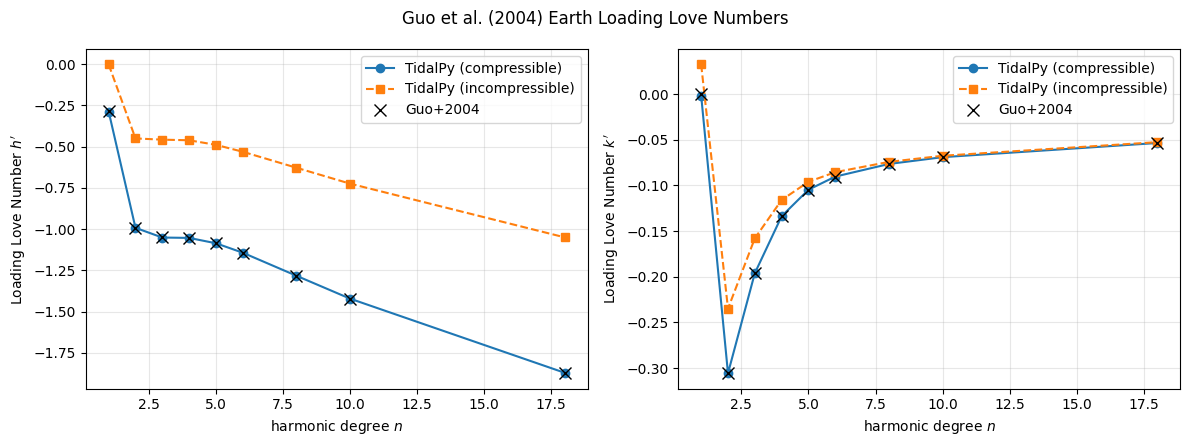

  n  h_TidalPy    h_Guo  k_TidalPy    k_Guo
  1    -0.2871  -0.2856    -0.0014  -0.0000
  2    -0.9919  -0.9909    -0.3058  -0.3051
  3    -1.0507  -1.0501    -0.1962  -0.1959
  4    -1.0529  -1.0528    -0.1337  -0.1335
  5    -1.0855  -1.0857    -0.1047  -0.1046
  6    -1.1427  -1.1433    -0.0903  -0.0902
  8    -1.2824  -1.2833    -0.0764  -0.0764
 10    -1.4212  -1.4226    -0.0690  -0.0689
 18    -1.8703  -1.8733    -0.0535  -0.0534


In [7]:
degrees = np.array([1, 2, 3, 4, 5, 6, 8, 10, 18])
guo_h_ref = -np.array([0.2856, 0.9909, 1.0501, 1.0528, 1.0857, 1.1433, 1.2833, 1.4226, 1.8733])
guo_kn_ref = -np.array([0, 0.6103, 0.5876, 0.5341, 0.5228, 0.5411, 0.61107, 0.6893, 0.961])
guo_k_ref = guo_kn_ref / degrees      # the paper plots n * k'

h_comp = np.array([guo(d, False)[0] for d in degrees])
k_comp = np.array([guo(d, False)[1] for d in degrees])
h_inco = np.array([guo(d, True)[0] for d in degrees])
k_inco = np.array([guo(d, True)[1] for d in degrees])

fig, (axh, axk) = plt.subplots(1, 2, figsize=(12, 4.5))
axh.plot(degrees, h_comp, "o-", label="TidalPy (compressible)")
axh.plot(degrees, h_inco, "s--", label="TidalPy (incompressible)")
axh.plot(degrees, guo_h_ref, "kx", ms=9, label="Guo+2004")
axh.set_ylabel("Loading Love Number $h'$")
axk.plot(degrees, k_comp, "o-", label="TidalPy (compressible)")
axk.plot(degrees, k_inco, "s--", label="TidalPy (incompressible)")
axk.plot(degrees, guo_k_ref, "kx", ms=9, label="Guo+2004")
axk.set_ylabel("Loading Love Number $k'$")
for ax in (axh, axk):
    ax.set_xlabel("harmonic degree $n$"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Guo et al. (2004) Earth Loading Love Numbers")
fig.tight_layout(); plt.show()

print(f"{'n':>3} {'h_TidalPy':>10} {'h_Guo':>8} {'k_TidalPy':>10} {'k_Guo':>8}")
for i, d in enumerate(degrees):
    print(f"{d:3d} {h_comp[i]:10.4f} {guo_h_ref[i]:8.4f} {k_comp[i]:10.4f} {guo_k_ref[i]:8.4f}")


## Farrell (1972)

The two-layer model, at degrees 3 and above. Its degree-2 solve does not converge for this liquid-core structure, so that degree is omitted.

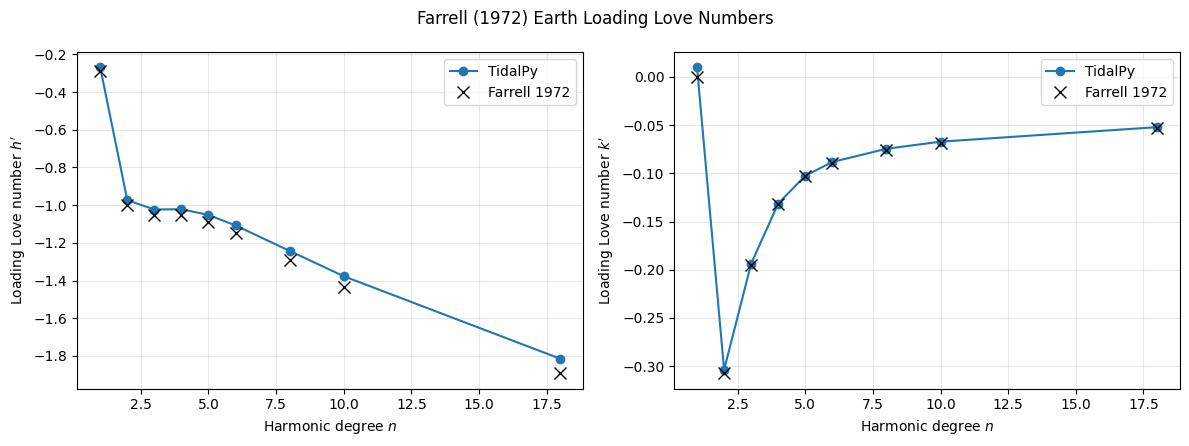

max |h' - reference| : 0.0781
max |k' - reference| : 0.0098


In [6]:
far_degrees = np.array([1, 2, 3, 4, 5, 6, 8, 10, 18])
far_h_ref = -np.array([0.29, 1.001, 1.052, 1.053, 1.088, 1.147, 1.291, 1.433, 1.893])
far_kn_ref = -np.array([0, 0.615, 0.585, 0.528, 0.516, 0.535, 0.604, 0.682, 0.952])
far_k_ref = far_kn_ref / far_degrees

fh = np.array([farrell(d, False)[0] for d in far_degrees])
fk = np.array([farrell(d, False)[1] for d in far_degrees])

fig, (axh, axk) = plt.subplots(1, 2, figsize=(12, 4.5))
axh.plot(far_degrees, fh, "o-", label="TidalPy")
axh.plot(far_degrees, far_h_ref, "kx", ms=9, label="Farrell 1972")
axh.set_ylabel("Loading Love number $h'$")
axk.plot(far_degrees, fk, "o-", label="TidalPy")
axk.plot(far_degrees, far_k_ref, "kx", ms=9, label="Farrell 1972")
axk.set_ylabel("Loading Love number $k'$")
for ax in (axh, axk):
    ax.set_xlabel("Harmonic degree $n$"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Farrell (1972) Earth Loading Love Numbers")
fig.tight_layout(); plt.show()

print(f"max |h' - reference| : {np.max(np.abs(fh - far_h_ref)):.4f}")
print(f"max |k' - reference| : {np.max(np.abs(fk - far_k_ref)):.4f}")
